In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Leer CSV tipo:
# Unix_time,GPS_data,motion_flag
# 1779391854447,$GPGGA,...,0
# ============================================================

def read_gps_csv(filepath):
    rows = []

    with open(filepath, "r", encoding="utf-8") as f:
        header = f.readline()  # saltar header

        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split(",")

            unix_time = parts[0]
            motion_flag = parts[-1]
            gps_data = ",".join(parts[1:-1])

            rows.append({
                "Unix_time": unix_time,
                "GPS_data": gps_data,
                "motion_flag": motion_flag
            })

    df = pd.DataFrame(rows)

    df["Unix_time"] = pd.to_numeric(df["Unix_time"], errors="coerce")
    df["motion_flag"] = pd.to_numeric(df["motion_flag"], errors="coerce")

    # Timestamp desde Unix en ms
    df["timestamp"] = pd.to_datetime(df["Unix_time"], unit="ms", errors="coerce")

    # Tiempo relativo
    df["t"] = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds()

    return df

In [2]:
def nmea_to_decimal(coord, direction):
    """
    Convierte coordenada NMEA ddmm.mmmm o dddmm.mmmm a grados decimales.
    direction: N, S, E, W
    """

    if pd.isna(coord) or coord == "":
        return np.nan

    coord = float(coord)

    degrees = int(coord // 100)
    minutes = coord - degrees * 100

    decimal = degrees + minutes / 60.0

    if direction in ["S", "W"]:
        decimal *= -1

    return decimal

In [3]:
def parse_nmea_row(sentence):
    """
    Extrae datos básicos desde GPGGA y GPRMC.
    Retorna diccionario.
    """

    out = {
        "type": None,
        "gps_time": np.nan,
        "lat": np.nan,
        "lon": np.nan,
        "alt_m": np.nan,
        "fix_quality": np.nan,
        "num_sat": np.nan,
        "hdop": np.nan,
        "speed_knots": np.nan,
        "speed_kmh": np.nan,
        "course_deg": np.nan,
        "status": None
    }

    if not isinstance(sentence, str):
        return out

    # Quitar checksum del último campo si existe
    sentence_clean = sentence.split("*")[0]
    fields = sentence_clean.split(",")

    if len(fields) == 0:
        return out

    msg_type = fields[0]
    out["type"] = msg_type

    # --------------------------------------------------------
    # GPGGA:
    # $GPGGA,time,lat,N/S,lon,E/W,fix,num_sat,hdop,alt,M,...
    # --------------------------------------------------------
    if msg_type in ["$GPGGA", "$GNGGA"]:
        try:
            out["gps_time"] = fields[1]

            lat_raw = fields[2]
            lat_dir = fields[3]
            lon_raw = fields[4]
            lon_dir = fields[5]

            out["lat"] = nmea_to_decimal(lat_raw, lat_dir)
            out["lon"] = nmea_to_decimal(lon_raw, lon_dir)

            out["fix_quality"] = pd.to_numeric(fields[6], errors="coerce")
            out["num_sat"] = pd.to_numeric(fields[7], errors="coerce")
            out["hdop"] = pd.to_numeric(fields[8], errors="coerce")
            out["alt_m"] = pd.to_numeric(fields[9], errors="coerce")

        except Exception:
            pass

    # --------------------------------------------------------
    # GPRMC:
    # $GPRMC,time,status,lat,N/S,lon,E/W,speed_knots,course,date,...
    # --------------------------------------------------------
    elif msg_type in ["$GPRMC", "$GNRMC"]:
        try:
            out["gps_time"] = fields[1]
            out["status"] = fields[2]

            lat_raw = fields[3]
            lat_dir = fields[4]
            lon_raw = fields[5]
            lon_dir = fields[6]

            out["lat"] = nmea_to_decimal(lat_raw, lat_dir)
            out["lon"] = nmea_to_decimal(lon_raw, lon_dir)

            out["speed_knots"] = pd.to_numeric(fields[7], errors="coerce")
            out["speed_kmh"] = out["speed_knots"] * 1.852

            out["course_deg"] = pd.to_numeric(fields[8], errors="coerce")

        except Exception:
            pass

    return out

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


filepath = "GPSlog__1.csv"

df = read_gps_csv(filepath)

parsed = df["GPS_data"].apply(parse_nmea_row)
df_parsed = pd.DataFrame(parsed.tolist())

df_gps = pd.concat([df, df_parsed], axis=1)

print(df_gps.head())
print(df_gps["type"].value_counts())

       Unix_time                                           GPS_data  \
0  1779389613248  $GPRMC,185122.000,A,1205.9938,S,07701.4557,W,0...   
1  1779389613248  $GPGGA,185123.000,1205.9938,S,07701.4557,W,2,0...   
2  1779389613249  $GPGSA,M,3,15,20,12,25,11,05,06,,,,,,1.9,1.3,1...   
3  1779389613250  $GPGSV,3,1,12,15,76,292,44,20,62,026,42,12,49,...   
4  1779389613251  $GPGSV,3,2,12,11,16,046,41,05,15,354,32,06,08,...   

   motion_flag               timestamp      t    type    gps_time        lat  \
0            0 2026-05-21 18:53:33.248  0.000  $GPRMC  185122.000 -12.099897   
1            0 2026-05-21 18:53:33.248  0.000  $GPGGA  185123.000 -12.099897   
2            0 2026-05-21 18:53:33.249  0.001  $GPGSA         NaN        NaN   
3            0 2026-05-21 18:53:33.250  0.002  $GPGSV         NaN        NaN   
4            0 2026-05-21 18:53:33.251  0.003  $GPGSV         NaN        NaN   

         lon  alt_m  fix_quality  num_sat  hdop  speed_knots  speed_kmh  \
0 -77.024262    N

In [5]:
df_pos = df_gps[
    (df_gps["type"].isin(["$GPGGA", "$GNGGA"])) &
    (df_gps["lat"].notna()) &
    (df_gps["lon"].notna())
].copy()

df_pos = df_pos.reset_index(drop=True)

print(df_pos[["timestamp", "lat", "lon", "alt_m", "fix_quality", "num_sat", "hdop"]].head())

                timestamp        lat        lon  alt_m  fix_quality  num_sat  \
0 2026-05-21 18:53:33.248 -12.099897 -77.024262  142.9          2.0      7.0   
1 2026-05-21 18:53:33.252 -12.099897 -77.024262  142.8          2.0      7.0   
2 2026-05-21 18:53:33.253 -12.099897 -77.024260  142.4          2.0      7.0   
3 2026-05-21 18:53:33.253 -12.099897 -77.024260  142.4          2.0      7.0   
4 2026-05-21 18:53:33.254 -12.099897 -77.024260  142.4          2.0      7.0   

   hdop  
0   1.3  
1   1.3  
2   1.3  
3   1.3  
4   1.3  


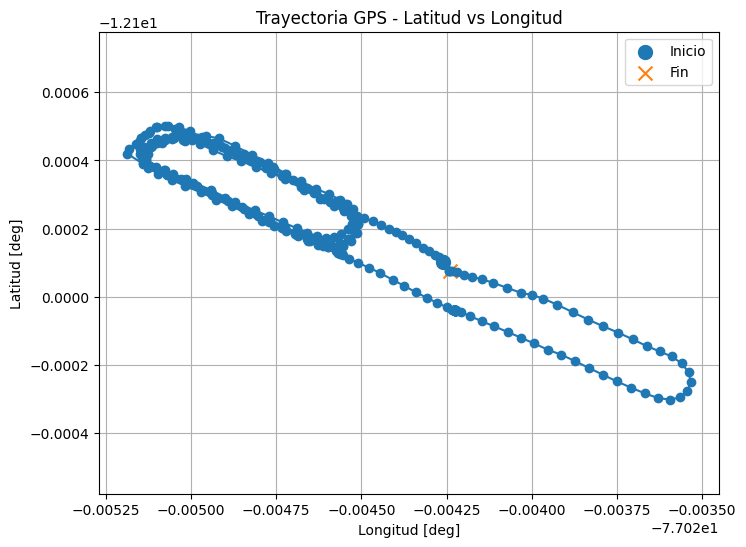

In [6]:
plt.figure(figsize=(8, 6))
plt.plot(df_pos["lon"], df_pos["lat"], marker="o", linestyle="-")

plt.xlabel("Longitud [deg]")
plt.ylabel("Latitud [deg]")
plt.title("Trayectoria GPS - Latitud vs Longitud")
plt.grid(True)
plt.axis("equal")

plt.scatter(df_pos["lon"].iloc[0], df_pos["lat"].iloc[0], marker="o", s=100, label="Inicio")
plt.scatter(df_pos["lon"].iloc[-1], df_pos["lat"].iloc[-1], marker="x", s=100, label="Fin")
plt.legend()

plt.show()

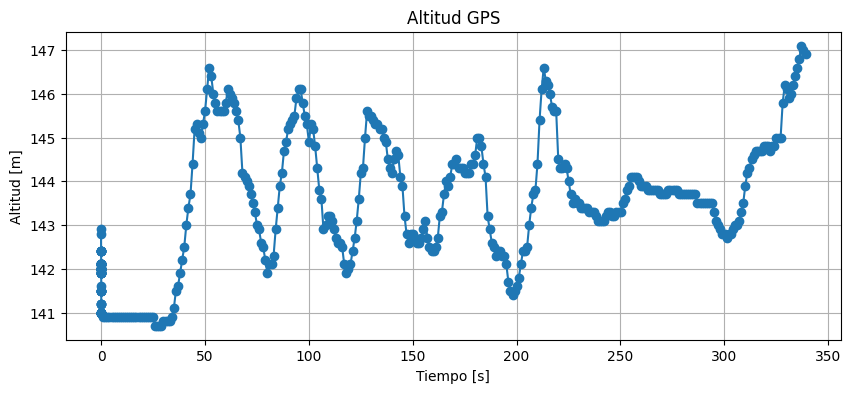

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(df_pos["t"], df_pos["alt_m"], marker="o")

plt.xlabel("Tiempo [s]")
plt.ylabel("Altitud [m]")
plt.title("Altitud GPS")
plt.grid(True)

plt.show()

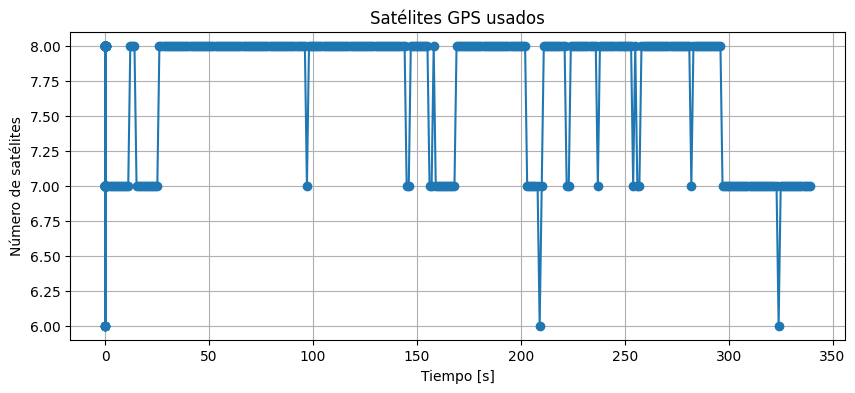

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(df_pos["t"], df_pos["num_sat"], marker="o")

plt.xlabel("Tiempo [s]")
plt.ylabel("Número de satélites")
plt.title("Satélites GPS usados")
plt.grid(True)

plt.show()

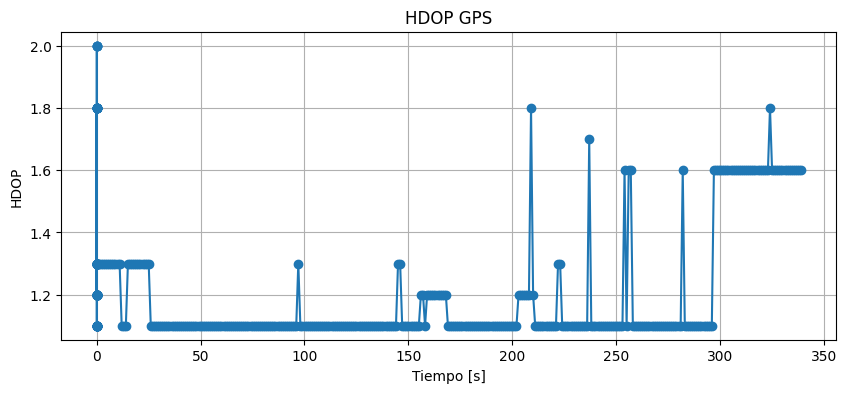

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(df_pos["t"], df_pos["hdop"], marker="o")

plt.xlabel("Tiempo [s]")
plt.ylabel("HDOP")
plt.title("HDOP GPS")
plt.grid(True)

plt.show()

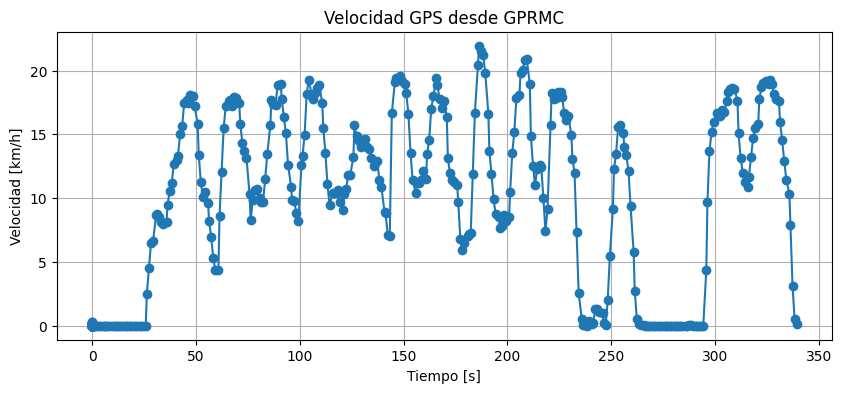

In [10]:
df_rmc = df_gps[
    (df_gps["type"].isin(["$GPRMC", "$GNRMC"])) &
    (df_gps["speed_kmh"].notna())
].copy()

df_rmc = df_rmc.reset_index(drop=True)

plt.figure(figsize=(10, 4))
plt.plot(df_rmc["t"], df_rmc["speed_kmh"], marker="o")

plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad [km/h]")
plt.title("Velocidad GPS desde GPRMC")
plt.grid(True)

plt.show()

In [11]:
def latlon_to_local_m(lat, lon, lat0, lon0):
    """
    Aproximación local ENU simple:
    x Este [m]
    y Norte [m]
    """
    R_earth = 6378137.0

    lat_rad = np.deg2rad(lat)
    lon_rad = np.deg2rad(lon)
    lat0_rad = np.deg2rad(lat0)
    lon0_rad = np.deg2rad(lon0)

    x = (lon_rad - lon0_rad) * np.cos(lat0_rad) * R_earth
    y = (lat_rad - lat0_rad) * R_earth

    return x, y

In [12]:
lat0 = df_pos["lat"].iloc[0]
lon0 = df_pos["lon"].iloc[0]

df_pos["x_m"], df_pos["y_m"] = latlon_to_local_m(
    df_pos["lat"],
    df_pos["lon"],
    lat0,
    lon0
)

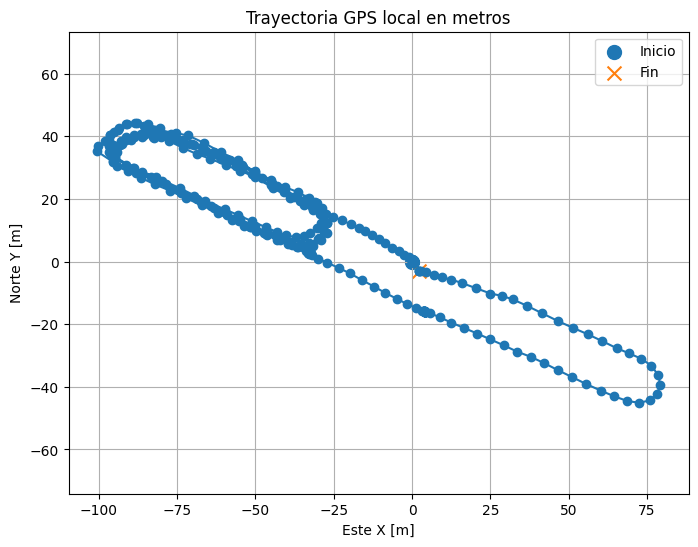

In [13]:
plt.figure(figsize=(8, 6))
plt.plot(df_pos["x_m"], df_pos["y_m"], marker="o")

plt.xlabel("Este X [m]")
plt.ylabel("Norte Y [m]")
plt.title("Trayectoria GPS local en metros")
plt.grid(True)
plt.axis("equal")

plt.scatter(df_pos["x_m"].iloc[0], df_pos["y_m"].iloc[0], s=100, label="Inicio")
plt.scatter(df_pos["x_m"].iloc[-1], df_pos["y_m"].iloc[-1], marker="x", s=100, label="Fin")
plt.legend()

plt.show()